In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

In [27]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from sh518880 import *

In [96]:
instrument_id = '518880'
trade_ymd = '20260319'

param_dict = {
        'instrument_id': instrument_id,
        'trade_ymd': trade_ymd,
    "window_size": 60,
    "volume_is_cumulative": False,

    "threshold_sigma": 3,
    "drift_sigma": 3,

    "eff_floor": 0.5,
    "volume_power": 1,
    "factor_clip": 100.0,
}

In [97]:
model_path = None
from strategy import StrategyDemo
strategy = StrategyDemo(model_path, param_dict)

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 79 个有数据的交易日
-> 过滤后剩余 79 个有数据的交易日
-> 过滤掉 651 个无数据日期: ['20250101', '20250102', '20250103', '20250104', '20250105', '20250106', '20250107', '20250108', '20250109', '20250110']...
-> 回测标的: 518880 (20250101 - 20261231)
-> 任务分配: 共 79 天，使用 4 个核心并行计算...


[SpawnPoolWorker-138] 日期 20250901 完成 | 盈亏: 5.20 | 成交: 25次 | 胜率: 40.0% | 平均持仓: 375.7快照
[SpawnPoolWorker-137] 日期 20251103 完成 | 盈亏: -2.90 | 成交: 24次 | 胜率: 41.7% | 平均持仓: 447.5快照
[SpawnPoolWorker-139] 日期 20251229 完成 | 盈亏: -8.50 | 成交: 26次 | 胜率: 19.2% | 平均持仓: 350.2快照
[SpawnPoolWorker-140] 日期 20260305 完成 | 盈亏: -0.70 | 成交: 24次 | 胜率: 33.3% | 平均持仓: 398.8快照
[SpawnPoolWorker-138] 日期 20250903 完成 | 盈亏: -3.60 | 成交: 22次 | 胜率: 9.1% | 平均持仓: 465.9快照
[SpawnPoolWorker-137] 日期 20251105 完成 | 盈亏: -6.10 | 成交: 34次 | 胜率: 29.4% | 平均持仓: 260.0快照
[SpawnPoolWorker-139] 日期 20251231 完成 | 盈亏: 9.00 | 成交: 25次 | 胜率: 64.0% | 平均持仓: 383.8快照
[SpawnPoolWorker-140] 日期 20260309 完成 | 盈亏: -2.90 | 成交: 23次 | 胜率: 39.1% | 平均持仓: 429.7快照
[SpawnPoolWorker-138] 日期 20250905 完成 | 盈亏: -1.90 | 成交: 22次 | 胜率: 18.2% | 平均持仓: 377.9快照
[SpawnPoolWorker-137] 日期 20251107 完成 | 盈亏: -4.00 | 成交: 35次 | 胜率: 20.0% | 平均持仓: 256.9快照
[SpawnPoolWorker-139] 日期 20260105 完成 | 盈亏: -8.50 | 成交: 29次 | 胜率: 20.7% | 平均持仓: 288.8快照
[SpawnPoolWorker-140] 日期 20260311 完成 | 盈亏: 0.7

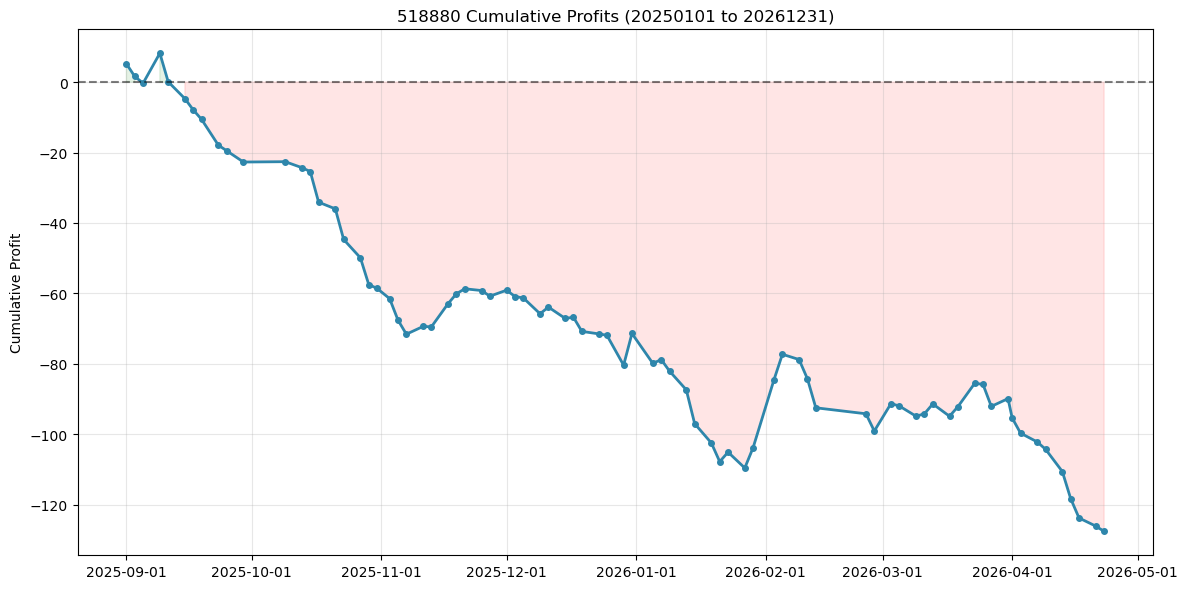


并行回测结果汇总:
{'测试天数': 79, '累计总盈亏': np.float64(-127.6), '总成交次数': 2170, '盈利交易次数': 727, '亏损交易次数': 1443, '加权每手胜率%': np.float64(33.5), '日均盈亏': np.float64(-1.62), '胜率(天)%': 27.85, '盈亏比(日均)': np.float64(1.13), '最大单日盈利': 19.3, '最大单日亏损': -9.6, '每笔交易平均盈利': np.float64(-0.06), '加权平均持仓时间(快照)': np.float64(339.26)}


In [98]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20250101",
    end_ymd="20261231",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4,
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)
print(summary)

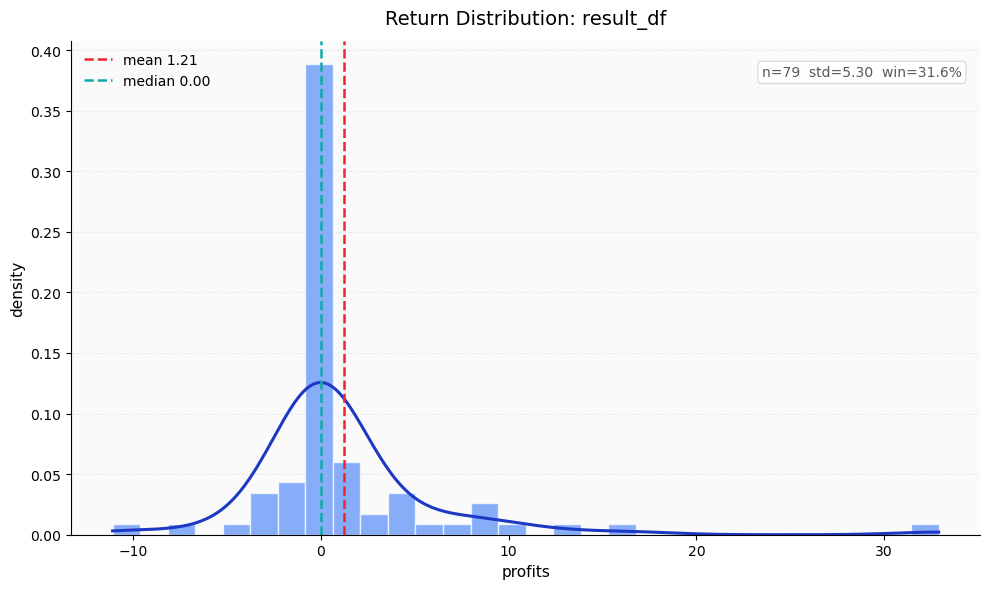

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Return Distribution: result_df'}, xlabel='profits', ylabel='density'>,
 {'count': 79,
  'mean': 1.210126582278481,
  'median': 0.0,
  'std': 5.2951984766246865,
  'min': -11.1,
  'max': 32.9,
  'positive_ratio': 0.31645569620253167})

In [12]:
from tools import plot_return_distribution
plot_return_distribution(result_df = result_df)

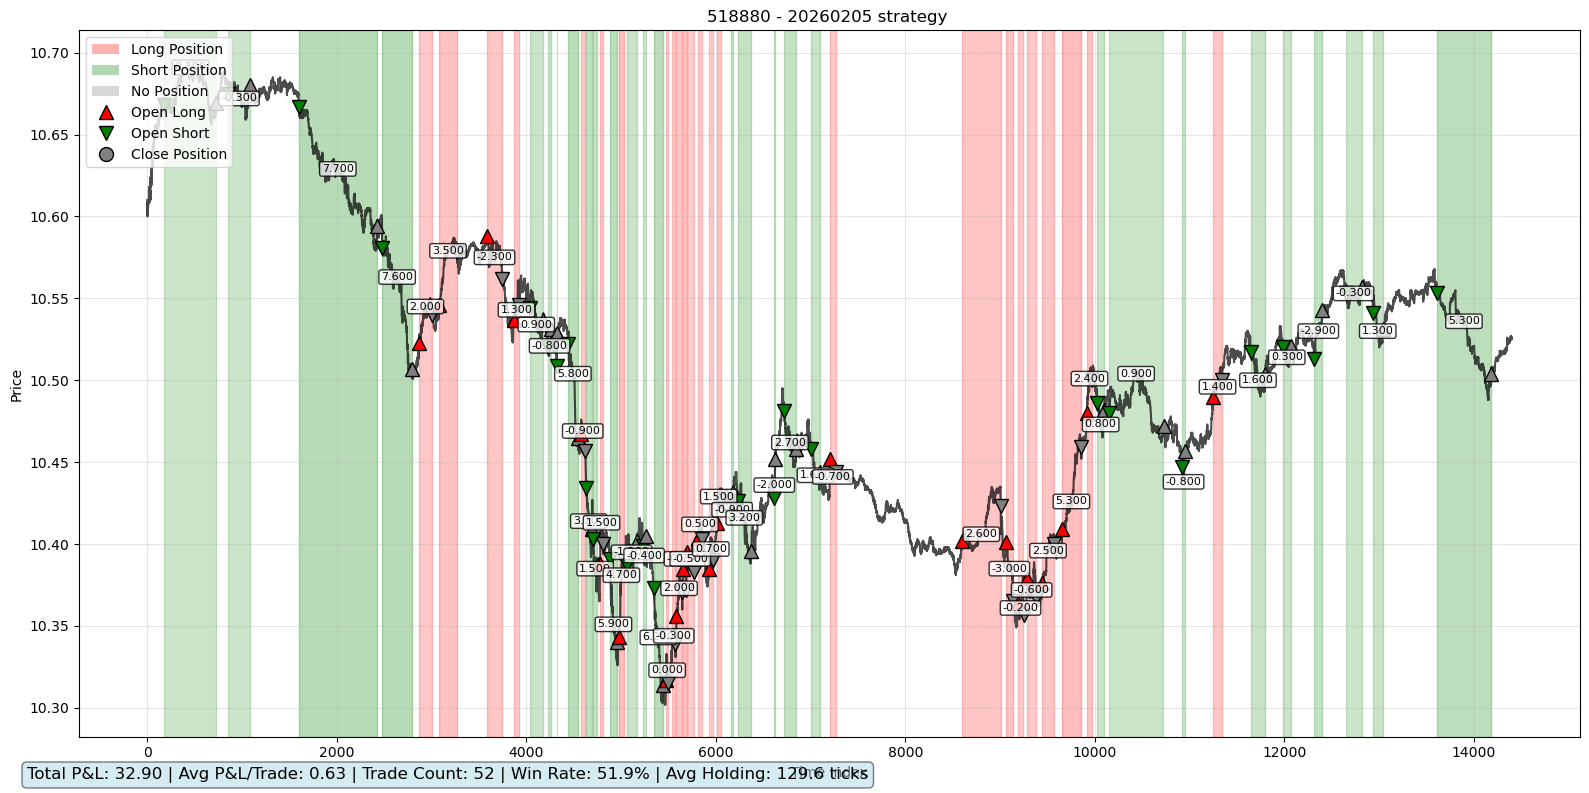

In [24]:
from single_day_backtest import single_day_backtest,plot_delta_history

hh = single_day_backtest(instrument_id,'20260205',StrategyDemo,model_path,param_dict,official = False)